## SDO/AIA warm up
### 1단계: 세 파장의 자료 검색

In [1]:
import astropy.units as u

from sunpy.net import Fido
from sunpy.net import attrs as a

/Users/jyson/miniconda3/envs/sun_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
start_time = "2011-06-07 06:33:00"
end_time   = "2011-06-07 06:34:00"

time_range = a.Time(start_time, end_time)

In [3]:
result_171 = Fido.search(
    time_range,
    a.Instrument.aia,
    a.Wavelength(171 * u.angstrom)
)

result_193 = Fido.search(
    time_range,
    a.Instrument.aia,
    a.Wavelength(193 * u.angstrom)
)

result_304 = Fido.search(
    time_range,
    a.Instrument.aia,
    a.Wavelength(304 * u.angstrom)
)

In [4]:
print("AIA 171 Å")
print(result_171)

print("\nAIA 193 Å")
print(result_193)

print("\nAIA 304 Å")
print(result_304)

AIA 171 Å
Results from 1 Provider:

6 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport
Total estimated size: 406.733 Mbyte

       Start Time               End Time        Source Instrument   Wavelength   Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                     Angstrom                                                                        Mibyte 
----------------------- ----------------------- ------ ---------- -------------- -------- --------- -------- ------------ ------------- ----------- --------
2011-06-07 06:33:02.000 2011-06-07 06:33:03.000    SDO        AIA 171.0 .. 171.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844
2011-06-07 06:33:12.000 2011-06-07 06:33:13.000    SDO        AIA 171.0 .. 171.0     JSOC intensity   NARROW         4096          4096    FULLDISK

### 2단계: 원하는 행만 선택하기

In [5]:
selected_171 = result_171[0, 3]
selected_193 = result_193[0, 2]
selected_304 = result_304[0, 0]

In [6]:
print(selected_171)
print(selected_193)
print(selected_304)

       Start Time               End Time        Source Instrument   Wavelength   Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size            fileid         
                                                                     Angstrom                                                                        Mibyte                          
----------------------- ----------------------- ------ ---------- -------------- -------- --------- -------- ------------ ------------- ----------- -------- ------------------------
2011-06-07 06:33:36.000 2011-06-07 06:33:37.000    SDO        AIA 171.0 .. 171.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844 aia__lev1:171:1086503651
       Start Time               End Time        Source Instrument   Wavelength   Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size            fileid         
                                                                     Angstrom             

In [7]:
from pathlib import Path

download_dir = Path("../data/aia_multiwavelength")
download_dir.mkdir(parents=True, exist_ok=True)

files_171 = Fido.fetch(selected_171, path=download_dir)
files_193 = Fido.fetch(selected_193, path=download_dir)
files_304 = Fido.fetch(selected_304, path=download_dir)

Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [01:30<?, ?file/s]2026-08-20 18:40:06 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1086503651-1086503651 failed to download with exception
Timeout on reading data from socket
Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [01:30<?, ?file/s]


1/0 files failed to download. Please check `.errors` for details


Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [01:30<?, ?file/s]2026-08-20 18:41:39 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=193_1086503647-1086503647 failed to download with exception
Timeout on reading data from socket
Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [01:30<?, ?file/s]


1/0 files failed to download. Please check `.errors` for details


Files Downloaded:   0%|                                                                                                                                                                     | 0/1 [00:00<?, ?file/s]
aia.lev1.304A_2011_06_07T06_33_32.12Z.image_lev1.fits:   0%|                                                                                                                            | 0.00/9.52M [00:00<?, ?B/s]
aia.lev1.304A_2011_06_07T06_33_32.12Z.image_lev1.fits:   0%|                                                                                                                | 1.02k/9.52M [00:53<138:18:30, 19.1B/s]
aia.lev1.304A_2011_06_07T06_33_32.12Z.image_lev1.fits:   0%|                                                                                                                  | 9.22k/9.52M [00:53<11:10:43, 236B/s]
aia.lev1.304A_2011_06_07T06_33_32.12Z.image_lev1.fits:   0%|▍                                                                                       

In [8]:
from sunpy.net import Fido
from sunpy.net import attrs as a
import astropy.units as u

from getpass import getpass

jsoc_email = getpass("JSOC registered email: ")

JSOC registered email:  ········


In [9]:
common_attrs = [
    a.jsoc.Series("aia.lev1_euv_12s"),
    a.jsoc.Segment.image,
    a.jsoc.Notify(jsoc_email),
]

jsoc_171 = Fido.search(
    a.Time("2011-06-07 06:33:30", "2011-06-07 06:33:42"),
    a.Wavelength(171 * u.angstrom),
    *common_attrs,
)

jsoc_193 = Fido.search(
    a.Time("2011-06-07 06:33:25", "2011-06-07 06:33:37"),
    a.Wavelength(193 * u.angstrom),
    *common_attrs,
)

jsoc_304 = Fido.search(
    a.Time("2011-06-07 06:33:26", "2011-06-07 06:33:38"),
    a.Wavelength(304 * u.angstrom),
    *common_attrs,
)

In [10]:
print("171 Å")
print(jsoc_171)

print("\n193 Å")
print(jsoc_193)

print("\n304 Å")
print(jsoc_304)

171 Å
Results from 1 Provider:

2 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

       T_REC         TELESCOP INSTRUME WAVELNTH CAR_ROT
-------------------- -------- -------- -------- -------
2011-06-07T06:33:26Z  SDO/AIA    AIA_3      171    2111
2011-06-07T06:33:38Z  SDO/AIA    AIA_3      171    2111



193 Å
Results from 1 Provider:

2 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

       T_REC         TELESCOP INSTRUME WAVELNTH CAR_ROT
-------------------- -------- -------- -------- -------
2011-06-07T06:33:26Z  SDO/AIA    AIA_2      193    2111
2011-06-07T06:33:38Z  SDO/AIA    AIA_2      193    2111



304 Å
Results from 1 Provider:

1 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

       T_REC         TELESCOP INSTRUME WAVELNTH CAR_ROT
-------------------- -------- -------- -------- -------
2011-06-07T06:33:26Z  SDO/AIA    AIA_4      304    2111




- VSO의 Start Time: 실제 노출과 관련된 관측 시각
- JSOC의 T_REC: 자료를 일정한 cadence에 배치하기 위한 명목상 record time

In [11]:
### 첫 번째 행을 선택

selected_171 = jsoc_171[0, 0]
selected_193 = jsoc_193[0, 0]
selected_304 = jsoc_304[0, 0]

In [12]:
print(selected_171)
print(selected_193)
print(selected_304)

       T_REC                  T_OBS          WAVELNTH         DATE           FSN    EXPTIME  QUALITY    ORIGIN    TELESCOP INSTRUME        DATE__OBS                DATE-OBS        CAMERA IMG_TYPE EXPSDEV  INT_TIME WAVEUNIT WAVE_STR FID QUALLEV0 TOTVALS  DATAVALS MISSVALS PERCENTD DATAMIN DATAMAX DATAMEDN DATAMEAN DATARMS DATASKEW DATAKURT DATACENT DATAP01 DATAP10 DATAP25 DATAP75 DATAP90 DATAP95 DATAP98 DATAP99 NSATPIX OSCNMEAN OSCNRMS       FLAT_REC      NSPIKES  CTYPE1  CUNIT1 CRVAL1  CDELT1     CRPIX1    CTYPE2  CUNIT2 CRVAL2  CDELT2     CRPIX2    CROTA2     R_SUN             MPO_REC           INST_ROT IMSCL_MP    X0_MP       Y0_MP               ASD_REC              SAT_Y0    SAT_Z0  SAT_ROT  ACS_MODE ACS_ECLP ACS_SUNP ACS_SAFE ACS_CGT                    ORB_REC                        DSUN_REF        DSUN_OBS      RSUN_REF   RSUN_OBS    GAEX_OBS     GAEY_OBS     GAEZ_OBS      HAEX_OBS        HAEY_OBS       HAEZ_OBS    OBS_VR     OBS_VW      OBS_VN   CAR_ROT CRLT_OBS  CRLN_OBS  HGLN_O

In [17]:
from pathlib import Path
from sunpy.net import Fido

download_dir = Path("data/aia_multiwavelength")

files_171 = Fido.fetch(
    selected_171,
    path=download_dir
)

files_193 = Fido.fetch(
    selected_193,
    path=download_dir
)

files_304 = Fido.fetch(
    selected_304,
    path=download_dir
)

2026-08-20 18:50:39 - sunpy - WARNING: SunpyUserWarning: Downloading of sliced JSOC results is not supported. All the files present in the original response will be downloaded when passed to fetch().
2026-08-20 18:50:49 - drms - INFO: Export request pending. [id=JSOC_20260820_003318, status=2]
2026-08-20 18:50:49 - drms - INFO: Waiting for 5 seconds...
2026-08-20 18:50:54 - drms - INFO: Export request finished. [id=JSOC_20260820_003318, status=0]
2026-08-20 18:50:54 - sunpy - INFO: 2 URLs found for download. Full request totaling 21MB


INFO: 2 URLs found for download. Full request totaling 21MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.48file/s]
2026-08-20 18:50:56 - sunpy - WARNING: SunpyUserWarning: Downloading of sliced JSOC results is not supported. All the files present in the original response will be downloaded when passed to fetch().
2026-08-20 18:51:12 - drms - INFO: Export request pending. [id=JSOC_20260820_003349, status=2]
2026-08-20 18:51:12 - drms - INFO: Waiting for 5 seconds...
2026-08-20 18:51:17 - drms - INFO: Export request pending. [id=JSOC_20260820_003349, status=1]
2026-08-20 18:51:17 - drms - INFO: Waiting for 10 seconds...
2026-08-20 18:51:28 - drms - INFO: Export request pending. [id=JSOC_20260820_003349, status=1]
2026-08-20 18:51:28 - drms - INFO: Waiting for 10 seconds...
2026-08-20 18:51:38 - drms - INFO: Export request pending. [id=JSOC_20260820_003349, status=1]
2026-08-20 18:51:38 - drm

INFO: 2 URLs found for download. Full request totaling 21MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.54file/s]
2026-08-20 18:52:21 - drms - INFO: Export request pending. [id=JSOC_20260820_003355, status=2]
2026-08-20 18:52:21 - drms - INFO: Waiting for 5 seconds...
2026-08-20 18:52:27 - drms - INFO: Export request pending. [id=JSOC_20260820_003355, status=1]
2026-08-20 18:52:27 - drms - INFO: Waiting for 10 seconds...
2026-08-20 18:52:37 - drms - INFO: Export request pending. [id=JSOC_20260820_003355, status=1]
2026-08-20 18:52:37 - drms - INFO: Waiting for 10 seconds...
2026-08-20 18:52:48 - drms - INFO: Export request pending. [id=JSOC_20260820_003355, status=1]
2026-08-20 18:52:48 - drms - INFO: Waiting for 10 seconds...
2026-08-20 18:52:59 - drms - INFO: Export request pending. [id=JSOC_20260820_003355, status=1]
2026-08-20 18:52:59 - drms - INFO: Waiting for 10 seconds...
2026-08-

INFO: 1 URLs found for download. Full request totaling 9MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.15s/file]


In [18]:
import sunpy.map

map_171 = sunpy.map.Map(files_171[0])
map_193 = sunpy.map.Map(files_193[0])
map_304 = sunpy.map.Map(files_304[0])

print("171 Å:", map_171.date)
print("193 Å:", map_193.date)
print("304 Å:", map_304.date)

171 Å: 2011-06-07T06:33:36.344
193 Å: 2011-06-07T06:33:31.841
304 Å: 2011-06-07T06:33:32.124


- [0, 0] 접근 자체는 가능하지만, 그렇게 잘라낸 결과를 Fido.fetch()에 전달해 특정 파일만 다운로드하는 것은 지원되지 않는다

### 3단계: 세 파장 나란히 그리기

In [19]:
### 먼저 이미 존재하는 data file에 접근해서 allocate

from pathlib import Path

import astropy.units as u
from astropy.time import Time
import sunpy.map

In [20]:
download_dir = Path("../data/aia_multiwavelength")

fits_files = sorted(download_dir.glob("*.fits"))

print(f"찾은 FITS 파일: {len(fits_files)}개")

for filepath in fits_files:
    print(filepath)

찾은 FITS 파일: 6개
../data/aia_multiwavelength/aia.lev1.304A_2011_06_07T06_33_32.12Z.image_lev1.fits
../data/aia_multiwavelength/aia.lev1_euv_12s.2011-06-07T063333Z.193.image_lev1.fits
../data/aia_multiwavelength/aia.lev1_euv_12s.2011-06-07T063334Z.304.image_lev1.fits
../data/aia_multiwavelength/aia.lev1_euv_12s.2011-06-07T063337Z.171.image_lev1.fits
../data/aia_multiwavelength/aia.lev1_euv_12s.2011-06-07T063346Z.193.image_lev1.fits
../data/aia_multiwavelength/aia.lev1_euv_12s.2011-06-07T063351Z.171.image_lev1.fits


In [21]:
all_maps = [sunpy.map.Map(filepath) for filepath in fits_files]

In [22]:
for i, smap in enumerate(all_maps):
    print(
        i,
        smap.wavelength,
        smap.date,
        smap.meta.get("filename", "filename 정보 없음")
    )

0 304.0 Angstrom 2011-06-07T06:33:32.120 filename 정보 없음
1 193.0 Angstrom 2011-06-07T06:33:31.841 filename 정보 없음
2 304.0 Angstrom 2011-06-07T06:33:32.124 filename 정보 없음
3 171.0 Angstrom 2011-06-07T06:33:36.344 filename 정보 없음
4 193.0 Angstrom 2011-06-07T06:33:46.190 filename 정보 없음
5 171.0 Angstrom 2011-06-07T06:33:50.623 filename 정보 없음


In [23]:
target_time = Time("2011-06-07T06:33:33")

In [24]:
def select_nearest_map(maps, wavelength, target_time):
    candidates = [
        smap for smap in maps
        if round(smap.wavelength.to_value(u.angstrom)) == wavelength
    ]

    if not candidates:
        raise ValueError(f"AIA {wavelength} Å 파일을 찾지 못했습니다.")

    return min(
        candidates,
        key=lambda smap: abs((smap.date - target_time).sec)
    )

In [25]:
map_171 = select_nearest_map(all_maps, 171, target_time)
map_193 = select_nearest_map(all_maps, 193, target_time)
map_304 = select_nearest_map(all_maps, 304, target_time)

In [26]:
print("171 Å:", map_171.date)
print("193 Å:", map_193.date)
print("304 Å:", map_304.date)

171 Å: 2011-06-07T06:33:36.344
193 Å: 2011-06-07T06:33:31.841
304 Å: 2011-06-07T06:33:32.124


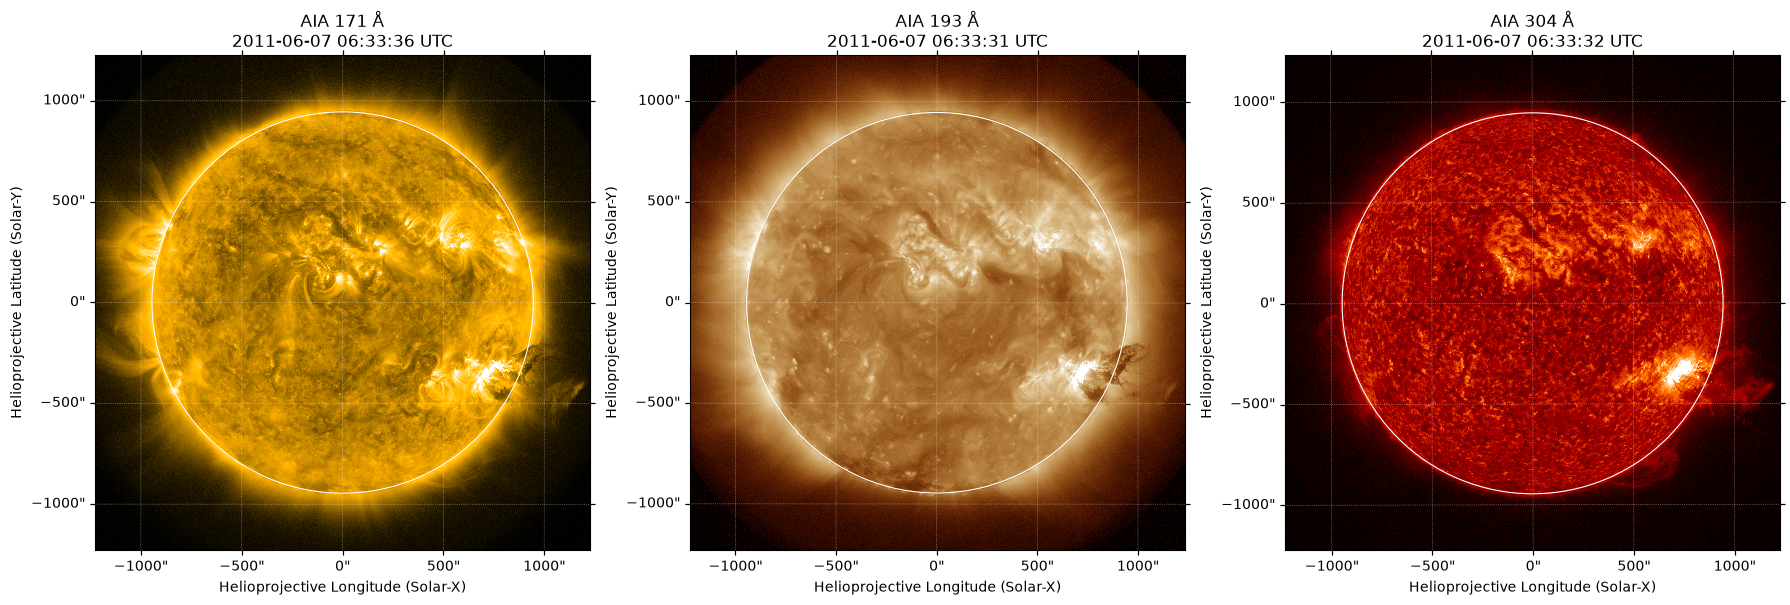

In [27]:
### plot 그리기

import matplotlib.pyplot as plt
import astropy.units as u

maps = [map_171, map_193, map_304]
wavelengths = [171, 193, 304]

fig = plt.figure(figsize=(18, 6))

for i, (smap, wavelength) in enumerate(zip(maps, wavelengths), start=1):
    ax = fig.add_subplot(1, 3, i, projection=smap)

    smap.plot(
        axes=ax,
        clip_interval=(1, 99.9) * u.percent
    )

    smap.draw_limb(axes=ax, color="white", linewidth=0.8)

    ax.set_title(
        f"AIA {wavelength} Å\n"
        f"{smap.date.strftime('%Y-%m-%d %H:%M:%S')} UTC"
    )

plt.tight_layout()
plt.show()

In [28]:
# 각 이미지의 색상은 해당 파장 영역대에서 common하게 쓰이는 colormap

print(map_171.plot_settings["cmap"])
print(map_193.plot_settings["cmap"])
print(map_304.plot_settings["cmap"])

sdoaia171
sdoaia193
sdoaia304


### 4단계: 동일한 영역 crop

In [29]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [30]:
# helioprojective 좌표 범위 적용하는 함수

def crop_active_region(smap):
    bottom_left = SkyCoord(
        450 * u.arcsec,
        -750 * u.arcsec,
        frame=smap.coordinate_frame
    )

    top_right = SkyCoord(
        1100 * u.arcsec,
        -100 * u.arcsec,
        frame=smap.coordinate_frame
    )

    return smap.submap(
        bottom_left,
        top_right=top_right
    )

In [31]:
# 세 파장 모두 crop

crop_171 = crop_active_region(map_171)
crop_193 = crop_active_region(map_193)
crop_304 = crop_active_region(map_304)

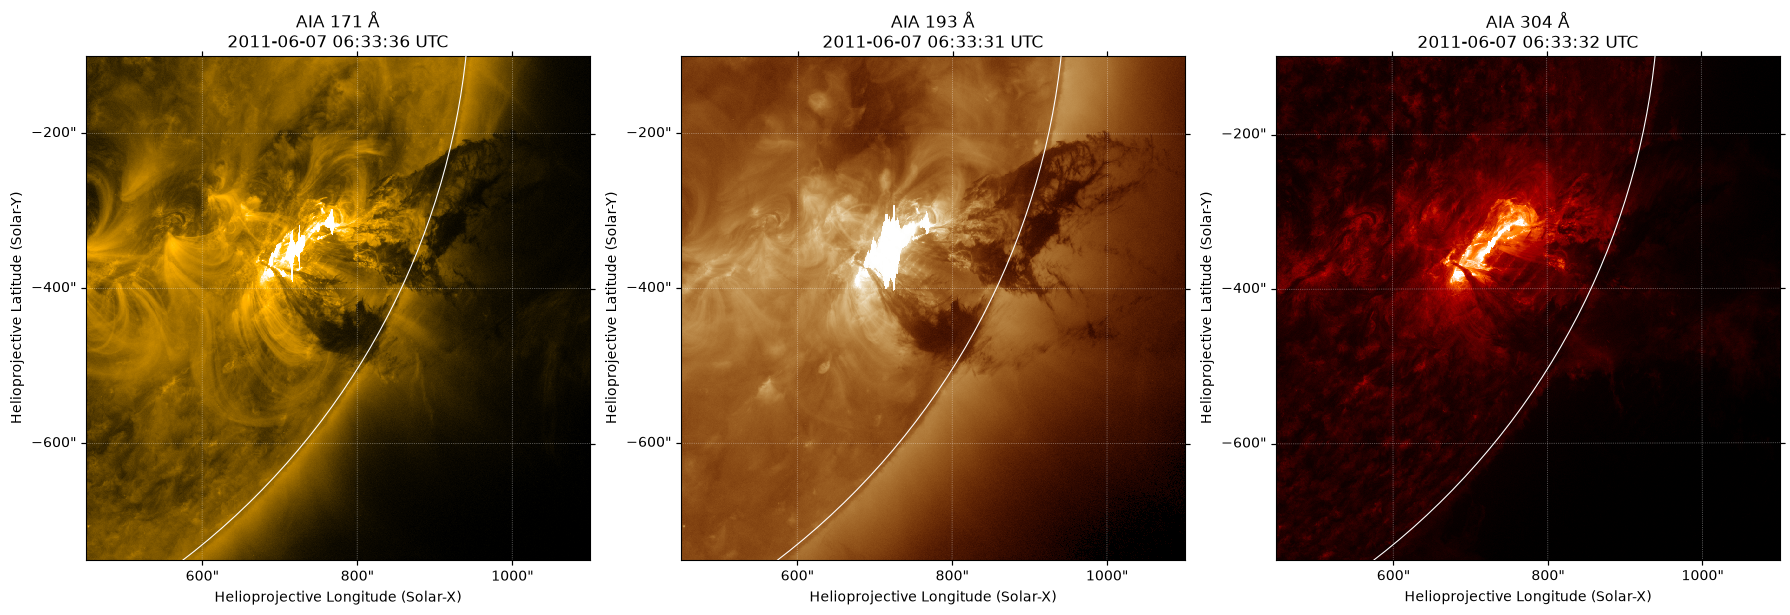

In [32]:
# crop된 이미지 비교

cropped_maps = [crop_171, crop_193, crop_304]
wavelengths = [171, 193, 304]

fig = plt.figure(figsize=(18, 6))

for i, (smap, wavelength) in enumerate(
    zip(cropped_maps, wavelengths),
    start=1
):
    ax = fig.add_subplot(1, 3, i, projection=smap)

    smap.plot(
        axes=ax,
        clip_interval=(1, 99.9) * u.percent
    )

    smap.draw_limb(
        axes=ax,
        color="white",
        linewidth=0.8
    )

    ax.set_title(
        f"AIA {wavelength} Å\n"
        f"{smap.date.strftime('%Y-%m-%d %H:%M:%S')} UTC"
    )

plt.tight_layout()
plt.show()

- 171 Å: 가늘고 긴 coronal loop들이 가장 선명하다. 특히 활동영역에서 왼쪽과 아래쪽으로 이어지는 자기장 구조가 잘 드러난다.
- 193 Å: 코로나 방출이 더 넓고 diffuse하게 보인다. 활동영역 오른쪽 위의 검은 그물 같은 구조는 차갑고 조밀한 분출 물질이 배경 EUV를 흡수하거나 가리면서 나타난 것으로 해석할 수 있다.
- 304 Å: 상대적으로 차가운 chromosphere/transition-region plasma가 강조된다. 밝은 저층 구조와 태양 가장자리 밖으로 이어지는 분출 물질이 두드러진다.

| 파장    | 주 방출선  |  대표 형성 온도 | 주로 보이는 구조                                   |
| ----- | ------ | --------: | ------------------------------------------- |
| 171 Å | Fe IX  |  약 0.6 MK | 조용한 코로나, coronal loop                       |
| 193 Å | Fe XII |  약 1.3 MK | 더 뜨거운 코로나, diffuse corona                   |
| 304 Å | He II  | 약 0.05 MK | chromosphere, transition region, prominence |


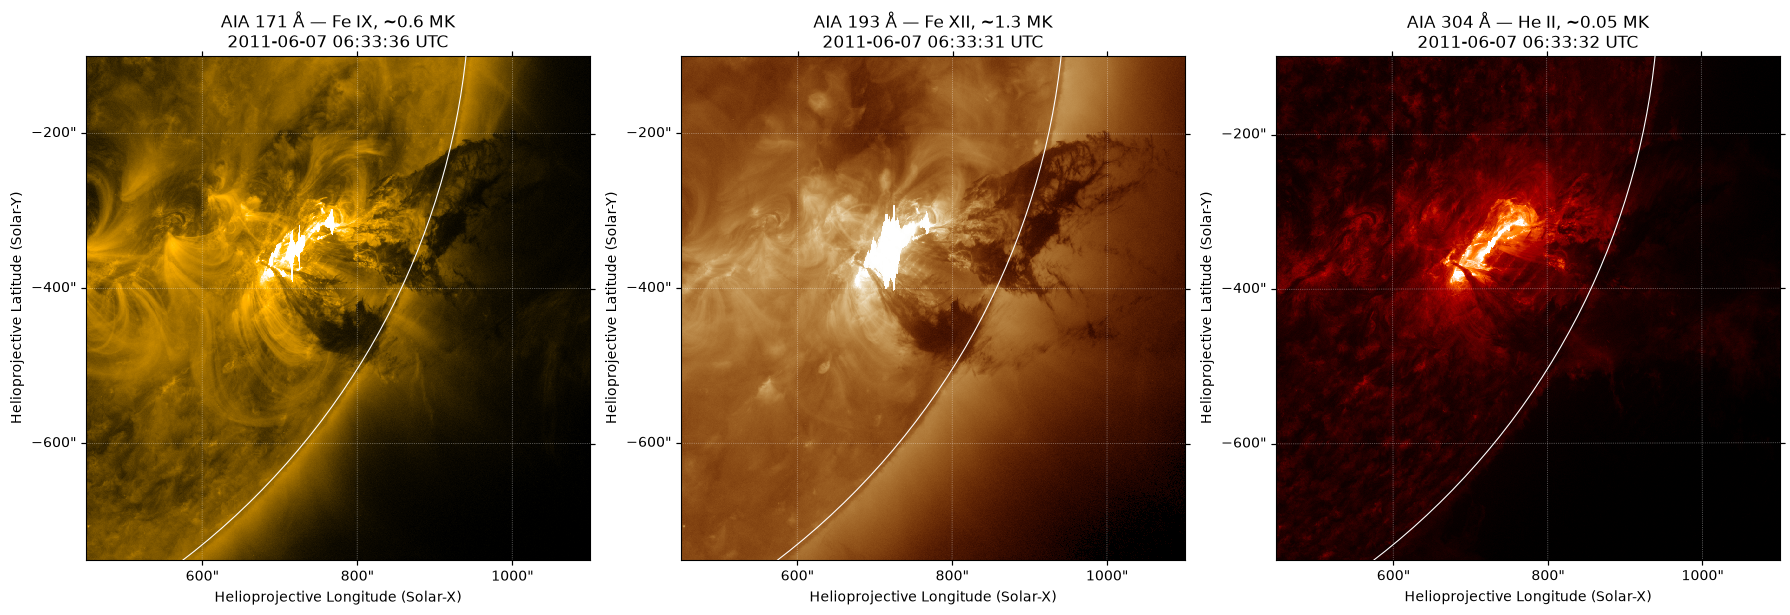

In [33]:
# 제목에 온도 정보 넣기

cropped_maps = [crop_171, crop_193, crop_304]
wavelengths = [171, 193, 304]

fig = plt.figure(figsize=(18, 6))

temperature_labels = {
    171: "Fe IX, ~0.6 MK",
    193: "Fe XII, ~1.3 MK",
    304: "He II, ~0.05 MK",
}

for i, (smap, wavelength) in enumerate(
    zip(cropped_maps, wavelengths),
    start=1
):
    ax = fig.add_subplot(1, 3, i, projection=smap)

    smap.plot(
        axes=ax,
        clip_interval=(1, 99.9) * u.percent
    )

    smap.draw_limb(
        axes=ax,
        color="white",
        linewidth=0.8
    )

    ax.set_title(
        f"AIA {wavelength} Å — {temperature_labels[wavelength]}\n"
        f"{smap.date.strftime('%Y-%m-%d %H:%M:%S')} UTC"
    )

plt.tight_layout()
plt.show()

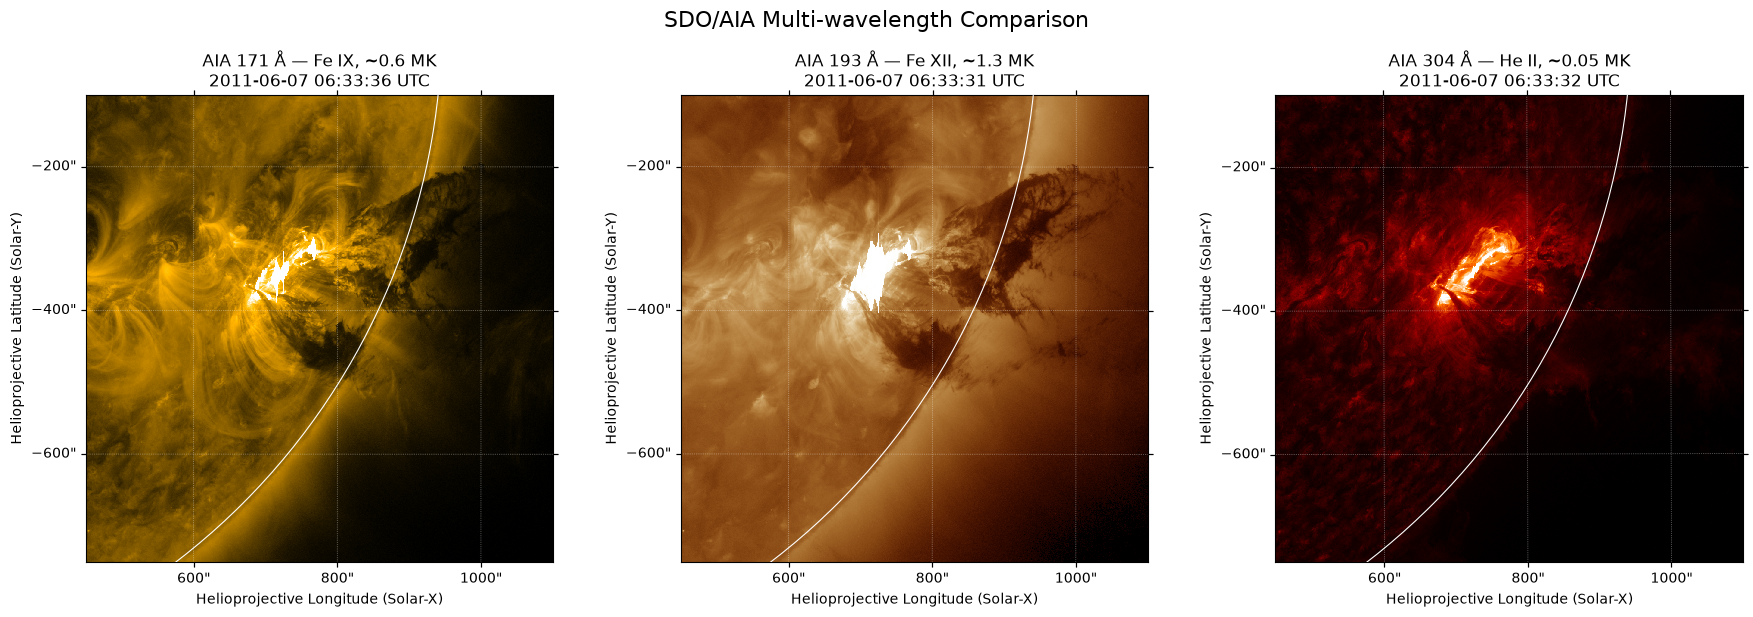

Saved to: /Users/jyson/SunProject/figures/aia_multiwavelength_comparison.png


In [34]:
from pathlib import Path
import matplotlib.pyplot as plt
import astropy.units as u

figure_dir = Path("/Users/jyson/SunProject/figures")
figure_dir.mkdir(exist_ok=True)

cropped_maps = [crop_171, crop_193, crop_304]
wavelengths = [171, 193, 304]

temperature_labels = {
    171: "Fe IX, ~0.6 MK",
    193: "Fe XII, ~1.3 MK",
    304: "He II, ~0.05 MK",
}

fig = plt.figure(figsize=(18, 6))

for i, (smap, wavelength) in enumerate(
    zip(cropped_maps, wavelengths),
    start=1
):
    ax = fig.add_subplot(1, 3, i, projection=smap)

    smap.plot(
        axes=ax,
        clip_interval=(1, 99.9) * u.percent
    )

    smap.draw_limb(
        axes=ax,
        color="white",
        linewidth=0.8
    )

    ax.set_title(
        f"AIA {wavelength} Å — {temperature_labels[wavelength]}\n"
        f"{smap.date.strftime('%Y-%m-%d %H:%M:%S')} UTC"
    )

fig.suptitle(
    "SDO/AIA Multi-wavelength Comparison",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

output_path = figure_dir / "aia_multiwavelength_comparison.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to: {output_path}")

## 간단한 정량 분석

In [35]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# 활동영역 내부의 밝은 loop 영역
active_bottom_left = SkyCoord(
    650 * u.arcsec,
    -470 * u.arcsec,
    frame=map_171.coordinate_frame
)

active_top_right = SkyCoord(
    750 * u.arcsec,
    -370 * u.arcsec,
    frame=map_171.coordinate_frame
)

# 비교용 quiet-Sun 영역
quiet_bottom_left = SkyCoord(
    -600 * u.arcsec,
    -470 * u.arcsec,
    frame=map_171.coordinate_frame
)

quiet_top_right = SkyCoord(
    -500 * u.arcsec,
    -370 * u.arcsec,
    frame=map_171.coordinate_frame
)

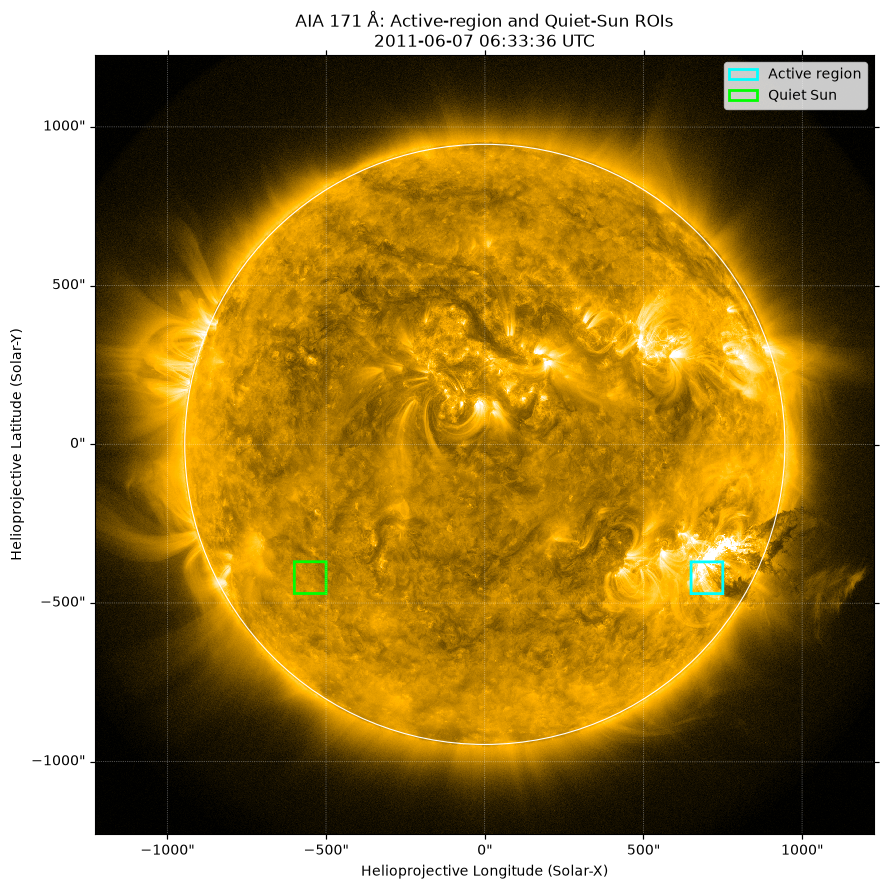

In [36]:
import matplotlib.pyplot as plt
import astropy.units as u

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection=map_171)

map_171.plot(
    axes=ax,
    clip_interval=(1, 99.9) * u.percent
)

map_171.draw_limb(
    axes=ax,
    color="white",
    linewidth=0.8
)

# Active-region ROI
map_171.draw_quadrangle(
    active_bottom_left,
    top_right=active_top_right,
    axes=ax,
    edgecolor="cyan",
    linewidth=2,
    label="Active region"
)

# Quiet-Sun ROI
map_171.draw_quadrangle(
    quiet_bottom_left,
    top_right=quiet_top_right,
    axes=ax,
    edgecolor="lime",
    linewidth=2,
    label="Quiet Sun"
)

ax.set_title(
    "AIA 171 Å: Active-region and Quiet-Sun ROIs\n"
    f"{map_171.date.strftime('%Y-%m-%d %H:%M:%S')} UTC"
)

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [37]:
# submap 및 기초 통계량 계산

import numpy as np

active_roi = map_171.submap(
    active_bottom_left,
    top_right=active_top_right
)

quiet_roi = map_171.submap(
    quiet_bottom_left,
    top_right=quiet_top_right
)

def intensity_stats(smap):
    data = smap.data
    finite_data = data[np.isfinite(data)]

    return {
        "mean": np.mean(finite_data),
        "median": np.median(finite_data),
        "std": np.std(finite_data),
        "min": np.min(finite_data),
        "max": np.max(finite_data),
        "n_pixels": finite_data.size,
    }

active_stats = intensity_stats(active_roi)
quiet_stats = intensity_stats(quiet_roi)

print("Active-region ROI")
for key, value in active_stats.items():
    print(f"{key:>8}: {value:.2f}" if isinstance(value, float) else f"{key:>8}: {value}")

print("\nQuiet-Sun ROI")
for key, value in quiet_stats.items():
    print(f"{key:>8}: {value:.2f}" if isinstance(value, float) else f"{key:>8}: {value}")

print(
    f"\nMean-intensity ratio (active / quiet): "
    f"{active_stats['mean'] / quiet_stats['mean']:.2f}"
)

Active-region ROI
    mean: 2045.25439453125
  median: 1363.0
     std: 2672.7294921875
     min: 145.0
     max: 16383.0
n_pixels: 28056

Quiet-Sun ROI
    mean: 294.6681823730469
  median: 290.0
     std: 80.17718505859375
     min: 113.0
     max: 697.0
n_pixels: 28224

Mean-intensity ratio (active / quiet): 6.94


In [38]:
# 포화 픽셀 비율 확인

saturation_level = 16383

active_saturated = np.sum(active_roi.data >= saturation_level)
active_finite = np.sum(np.isfinite(active_roi.data))

print("Saturated pixels:", active_saturated)
print(
    f"Saturated fraction: "
    f"{100 * active_saturated / active_finite:.3f}%"
)

Saturated pixels: 167
Saturated fraction: 0.595%


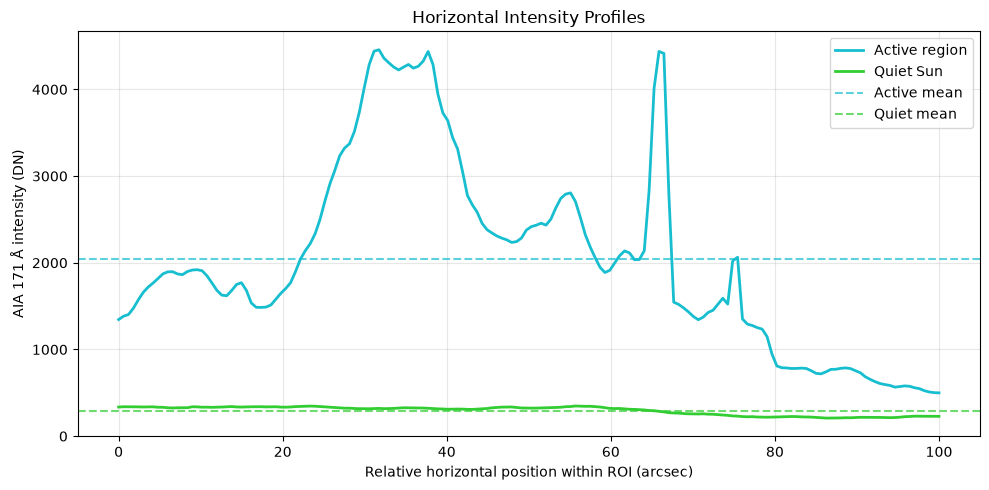

In [39]:
# 각 ROI에서 세로 방향으로 평균 내기 -> 가로 방향의 1차원 intensity profile 생성

active_profile = np.nanmean(active_roi.data, axis=0)
quiet_profile = np.nanmean(quiet_roi.data, axis=0)

# 두 ROI 내부에서의 상대적 가로 위치
active_x = np.linspace(0, 100, active_profile.size)
quiet_x = np.linspace(0, 100, quiet_profile.size)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    active_x,
    active_profile,
    color="tab:cyan",
    linewidth=2,
    label="Active region"
)

ax.plot(
    quiet_x,
    quiet_profile,
    color="limegreen",
    linewidth=2,
    label="Quiet Sun"
)

ax.axhline(
    active_stats["mean"],
    color="tab:cyan",
    linestyle="--",
    alpha=0.7,
    label="Active mean"
)

ax.axhline(
    quiet_stats["mean"],
    color="limegreen",
    linestyle="--",
    alpha=0.7,
    label="Quiet mean"
)

ax.set_xlabel("Relative horizontal position within ROI (arcsec)")
ax.set_ylabel("AIA 171 Å intensity (DN)")
ax.set_title("Horizontal Intensity Profiles")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

figure_dir = Path("../figures")
figure_dir.mkdir(exist_ok=True)

output_path = figure_dir / "aia171_roi_intensity_profiles.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Results

The AIA 171 Å active-region ROI is substantially brighter and more
spatially variable than the quiet-Sun ROI.

- Mean intensity ratio (active / quiet): 6.94
- Median intensity ratio (active / quiet): 4.70
- Saturated pixels in the active-region ROI: 167 (0.595%)

The active-region intensity profile contains broad enhancements and
sharp peaks associated with bright coronal structures, whereas the
quiet-Sun profile remains comparatively weak and uniform.

Because some active-region pixels reach the saturation level of
16383 DN, the mean and standard deviation may be biased upward.
The median-intensity ratio therefore provides a more robust comparison.

## Reproducibility check

- Kernel restarted before execution
- All cells executed sequentially
- No execution errors
- Figures regenerated successfully